# Comparaison des Deux Approches de Clustering : Direct (N1) vs. Marque × Gamme (N2)

## Deux philosophies de segmentation du même marché, confrontées sur les mêmes produits

---

**Contexte.** Ce projet a produit deux notebooks de clustering des produits technologiques Mytek.tn, construits
sur des philosophies délibérément différentes :

- **N1 — `Clustering_produits_technologiques.ipynb`.** Un unique K-Means par **catégorie entière** : tous les
  produits d'une catégorie (toutes marques confondues) sont clusterisés ensemble sur leurs caractéristiques
  techniques. Couverture de 100% par construction — chaque produit appartient à un cluster.
- **N2 — `Segmentation_Prix_Clustering_produits_technologiques.ipynb`.** Une segmentation **emboîtée** :
  catégorie → marque (marques trop rares écartées, `MIN_BRAND_COUNT`=5) → gamme de prix (Économique / Milieu de
  gamme / Premium, propre à chaque marque) → clustering K-Means **au sein** de chaque couple (marque, gamme),
  uniquement si l'effectif dépasse `CLUSTERING_MIN_N`=10. Couverture partielle par construction — une partie du
  catalogue retombe en profil descriptif.

**Pourquoi comparer.** Les deux notebooks répondent chacun à une question légitime, mais aucun des deux ne
dit si l'autre aurait pu suffire, ni où et pourquoi ils divergent. Ce notebook ne recalcule aucun clustering :
il **charge les labels déjà produits et persistés** par les deux notebooks (`outputs/labels/`, Phase 1 de cette
tâche) et les confronte sur sept axes : couverture analytique, qualité de séparation, robustesse, pouvoir
discriminant du prix, **accord inter-méthodes** (le cœur de la comparaison), lecture qualitative des
divergences, et synthèse finale.

**Clé de correspondance des produits.** Les deux notebooks sources identifient chaque produit par son `url`
(colonne `cle_produit` dans les CSV de labels) — le GTIN n'existe pas dans les données déjà prétraitées
(`data/processed/week_1/<catégorie>_clean.csv`), supprimé en amont par la sélection de caractéristiques. Le
taux de correspondance entre les deux jeux de labels, calculé au §1, confirme que l'écart entre N1 (100% du
catalogue) et N2 (un sous-ensemble) s'explique **entièrement** par le filtre `MIN_BRAND_COUNT` propre à N2 —
aucun produit n'est perdu pour une autre raison.

**Attention méthodologique — labels locaux vs. globaux.** Les clusters de N2 (`cluster_segmentation`) sont des
indices **locaux** à chaque couple (marque, gamme) : le cluster "0" chez SAMSUNG/Milieu de gamme et le cluster
"0" chez XIAOMI/Premium ne désignent pas le même groupe. Toute comparaison inter-méthodes ci-dessous utilise
donc une **clé composite** `marque | gamme | cluster local` pour identifier chaque groupe N2 sans confondre à
tort des clusters sans rapport provenant d'unités différentes (§5).

**Données.** `data/processed/week_1/<catégorie>_clean.csv` (les deux notebooks sources sont pinnés sur ce même
instantané) et les labels persistés `outputs/labels/clustering_direct_<catégorie>.csv` et `outputs/labels/produits_prix_cluster_semaine_<catégorie>.csv` (dédupliqué par `cle_produit`, une ligne par semaine dans ce dernier mais non utilisée ici)`.
`RANDOM_STATE`=42 pour toute opération stochastique (reconstruction de la classification hiérarchique dans le
test de robustesse, §4).


## 0. Imports, configuration et chemins de données


In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11, "font.size": 10,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42

# Racine du depot -- ce notebook vit dans notebooks/, comme les 4 autres.
REPO_ROOT = Path.cwd().resolve().parents[0]
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = Path.cwd().resolve()

PROCESSED_WEEK1 = REPO_ROOT / "data" / "processed" / "week_1"
LABELS_DIR = REPO_ROOT / "outputs" / "labels"
print("Répertoire de données :", PROCESSED_WEEK1)
print("Répertoire des labels :", LABELS_DIR)


Répertoire de données : C:\Users\MSI\Desktop\stage\data\processed\week_1
Répertoire des labels : C:\Users\MSI\Desktop\stage\outputs\labels


**Note sur les chemins.** Les deux notebooks sources sont explicitement pinnés sur l'instantané
`data/processed/week_1` (une observation par produit), pas sur le panel fusionné multi-semaines de la racine
`data/processed/` — ce notebook de comparaison réutilise le même instantané pour rester cohérent avec les
labels persistés, qui ont été calculés sur ces mêmes données.


## 1. Fonctions utilitaires

Reproduites ici à l'identique (même logique de construction de la matrice de caractéristiques que dans chacun
des deux notebooks sources, étendue pour exclure les colonnes de jointure propres à ce notebook de comparaison
— voir docstrings). Elles ne re-choisissent jamais *k* : elles ne font que **revalider** les partitions déjà
retenues par les notebooks sources à partir des labels persistés.


In [2]:
"""
Canonical source of every utility function/constant used in the comparison
notebook (Comparaison_Approches_Clustering.ipynb). Mirrors the pattern used
for the other generated notebooks: build_notebook_comparison.py reads this
file's own source text to embed IDENTICAL code into notebook cells, and
analysis_core_comparison.py imports it directly to precompute real
statistics for the interpretation prose -- no drift between what's baked
into the prose and what the notebook itself computes.

Les deux notebooks compares sont methodologiquement DIFFERENTS par
construction :
  - N1 (Clustering_produits_technologiques.ipynb) : un seul clustering
    KMeans par CATEGORIE ENTIERE. exclude = {url, nom, prix_tnd, marque}.
    Couverture = 100% par construction (toutes les categories sont assez
    grandes pour etre clusterisees directement).
  - N2 (Segmentation_Prix_Clustering_..._technologiques.ipynb) : un
    clustering par (marque x gamme de prix), avec un seuil minimal
    d'effectif (CLUSTERING_MIN_N=10) en dessous duquel aucune structure
    n'est tentee (profil descriptif a la place). exclude = {url, nom,
    prix_tnd, marque, gamme_prix}.

Les deux fonctions build_feature_matrix_n1/n2 ci-dessous DELEGUENT desormais
a _classify_features (src.models.hedonic_model, cf. correctif d'harmonisation
du 2026-08-01) pour la regle de classification continue/categorielle --
seul l'exclude set (propre a chaque notebook source, cf. ci-dessus) reste
local. Reproduites ici pour recalculer silhouette/ARI/Kruskal-Wallis a
partir des labels deja persistes (outputs/labels/), sans re-choisir k ni
re-inventer une methodologie tierce.

NOTE : le paragraphe "Mirrors the pattern used for the other generated
notebooks..." ci-dessus decrit un generateur (build_notebook_comparison.py/
analysis_core_comparison.py) qui n'existe pas dans ce depot (verifie --
aucune trace dans l'historique git) -- ce notebook est en realite maintenu
a la main, comme les autres.
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Racine du depot -- necessaire pour importer la source UNIQUE de la regle
# de classification continue/categorielle (cf. correctif d'harmonisation du
# 2026-08-01), jamais une seconde copie locale.
_REPO_ROOT = Path.cwd().resolve().parents[0]
if not (_REPO_ROOT / "src").exists():
    _REPO_ROOT = Path.cwd().resolve()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from src.models.hedonic_model import _classify_features

RANDOM_STATE = 42

CATEGORY_ORDER = ["pc_bureau", "pc_portables", "smartphones", "telephones_portables", "televiseurs"]
CATEGORY_LABELS = {
    "pc_bureau": "PC de Bureau", "pc_portables": "PC Portables", "smartphones": "Smartphones",
    "telephones_portables": "Téléphones Portables", "televiseurs": "Téléviseurs",
}
PALETTE = {
    "pc_bureau": "#2a78d6", "pc_portables": "#1baf7a", "smartphones": "#eda100",
    "telephones_portables": "#4a3aa7", "televiseurs": "#e34948",
}
CLUSTER_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834", "#008300"]
METHOD_COLORS = {"N1 (direct)": "#2a78d6", "N2 (marque × gamme)": "#e34948"}


def build_feature_matrix_n1(df):
    """Meme exclude set que build_feature_matrix() dans
    Clustering_produits_technologiques.ipynb, etendu avec cle_produit/
    cluster_direct (colonnes introduites par la JOINTURE de ce notebook de
    comparaison, absentes du DataFrame original de N1) : sans cette
    extension, cle_produit (quasi unique par ligne) serait one-hot-encodee
    en autant de colonnes que de produits, et cluster_direct fuiterait le
    label lui-meme dans les features -- corrompant totalement la
    silhouette. Classification continue/categorielle DELEGUEE a
    _classify_features (cf. correctif d'harmonisation)."""
    exclude = {"url", "nom", "prix_tnd", "marque", "cle_produit", "cluster_direct"}
    continuous, categorical = _classify_features(df, exclude=exclude)
    X_numeric = df[continuous].astype(float) if continuous else pd.DataFrame(index=df.index)
    X_categorical = (
        pd.get_dummies(df[categorical].astype(str), columns=categorical)
        if categorical else pd.DataFrame(index=df.index)
    )
    X_raw = pd.concat([X_numeric, X_categorical], axis=1)
    X_scaled = StandardScaler().fit_transform(X_raw)
    return X_scaled, X_raw


def build_feature_matrix_n2(df):
    """Meme exclude set que build_feature_matrix() dans
    Segmentation_Prix_Clustering_produits_technologiques.ipynb, etendu avec
    cle_produit, meme raison que build_feature_matrix_n1 (colonne de
    jointure quasi unique par ligne, introduite par ce notebook de
    comparaison, absente de l'original). Classification continue/
    categorielle DELEGUEE a _classify_features (cf. correctif
    d'harmonisation)."""
    exclude = {"url", "nom", "prix_tnd", "marque", "gamme_prix", "gamme", "categorie",
               "cluster_direct", "cluster_segmentation", "cle_produit"}
    continuous, categorical = _classify_features(df, exclude=exclude)
    X_numeric = df[continuous].astype(float) if continuous else pd.DataFrame(index=df.index)
    X_categorical = (
        pd.get_dummies(df[categorical].astype(str), columns=categorical)
        if categorical else pd.DataFrame(index=df.index)
    )
    X_raw = pd.concat([X_numeric, X_categorical], axis=1)
    X_scaled = StandardScaler().fit_transform(X_raw)
    return X_scaled, X_raw


def evaluate_unit(df_unit, labels, build_fn):
    """Recalcule, pour une unité déjà clusterisée (labels connus, k déjà
    choisi par le notebook d'origine) : silhouette, ARI (K-Means vs
    classification hiérarchique reconstruite avec le même k), test de
    Kruskal-Wallis sur le prix par cluster. Ne re-choisit JAMAIS k -- se
    contente de valider la partition déjà retenue."""
    X, X_raw = build_fn(df_unit)
    k = len(set(labels))
    sil = silhouette_score(X, labels) if k >= 2 else float("nan")

    if k >= 2:
        hier = AgglomerativeClustering(n_clusters=k)
        hier_labels = hier.fit_predict(X)
        ari = adjusted_rand_score(labels, hier_labels)
    else:
        ari = float("nan")

    groups = [df_unit.loc[np.asarray(labels) == c, "prix_tnd"].dropna() for c in sorted(set(labels))]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        h_stat, p_value = stats.kruskal(*groups)
    else:
        h_stat, p_value = float("nan"), float("nan")

    return {"n": len(df_unit), "k": k, "silhouette": sil, "ari": ari, "h_stat": h_stat, "p_value": p_value}


def weighted_mean(values, weights):
    """Moyenne pondérée par effectif, en ignorant les NaN (unités où k<2
    rend la silhouette/ARI non définies)."""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = ~np.isnan(values)
    if mask.sum() == 0:
        return float("nan")
    return float(np.average(values[mask], weights=weights[mask]))


def plot_coverage_comparison(coverage_df):
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(coverage_df))
    width = 0.35
    ax.bar(x - width / 2, coverage_df["couverture_n1"] * 100, width, label="N1 (direct)", color=METHOD_COLORS["N1 (direct)"])
    ax.bar(x + width / 2, coverage_df["couverture_n2"] * 100, width, label="N2 (marque × gamme)", color=METHOD_COLORS["N2 (marque × gamme)"])
    ax.set_xticks(x)
    ax.set_xticklabels([CATEGORY_LABELS[c] for c in coverage_df["categorie"]], rotation=20, ha="right")
    ax.set(title="Couverture analytique — part des produits réellement clusterisés",
           ylabel="Couverture (%)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()


def plot_metric_comparison(synth_df, metric_col_n1, metric_col_n2, title, ylabel):
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(synth_df))
    width = 0.35
    ax.bar(x - width / 2, synth_df[metric_col_n1], width, label="N1 (direct)", color=METHOD_COLORS["N1 (direct)"])
    ax.bar(x + width / 2, synth_df[metric_col_n2], width, label="N2 (marque × gamme)", color=METHOD_COLORS["N2 (marque × gamme)"])
    ax.set_xticks(x)
    ax.set_xticklabels([CATEGORY_LABELS[c] for c in synth_df["categorie"]], rotation=20, ha="right")
    ax.set(title=title, ylabel=ylabel)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()


def plot_inter_method_ari(inter_df):
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = [PALETTE[c] for c in inter_df["categorie"]]
    bars = ax.bar([CATEGORY_LABELS[c] for c in inter_df["categorie"]], inter_df["ari_inter_methodes"], color=colors)
    for bar, n in zip(bars, inter_df["n_compare"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"n={n}",
                ha="center", va="bottom", fontsize=8)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set(title="Accord inter-méthodes (ARI) — mêmes produits, deux chemins de clustering",
           ylabel="Indice de Rand ajusté (ARI)", xlabel="")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout(); plt.show()


def plot_contingency(contingency_df, category):
    """Colonnes N2 = clés composites "marque | gamme | cK" (K = indice local
    du cluster au sein de cette unité) -- nécessaire car un même entier K dans
    deux unités (marque, gamme) différentes ne désigne pas le même groupe."""
    fig, ax = plt.subplots(figsize=(max(9, 0.55 * contingency_df.shape[1]), 5.5))
    sns.heatmap(contingency_df, annot=True, fmt="d", cmap="Blues", cbar=True, ax=ax)
    ax.set(title=f"{CATEGORY_LABELS[category]} — Matrice de contingence N1 × N2",
           xlabel="Groupe N2 (marque × gamme × cluster local)", ylabel="Cluster N1 (direct)")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    plt.tight_layout(); plt.show()


## 2. Chargement des données et vérification du matching (clé = url)

Pour chaque catégorie : nombre de produits couverts par N1 (100% par construction), nombre couverts par N2
(après filtre `MIN_BRAND_COUNT`), et taux de correspondance entre les deux jeux de labels sur la clé `url`.


In [3]:
matching_rows = []
for cat in CATEGORY_ORDER:
    labels_n1 = pd.read_csv(LABELS_DIR / f"clustering_direct_{cat}.csv")
    labels_n2 = pd.read_csv(LABELS_DIR / f"produits_prix_cluster_semaine_{cat}.csv")
    urls_n1 = set(labels_n1["cle_produit"])
    urls_n2 = set(labels_n2["cle_produit"])
    n_intersection = len(urls_n1 & urls_n2)
    matching_rows.append({
        "Catégorie": CATEGORY_LABELS[cat],
        "N1 (produits)": len(urls_n1),
        "N2 (produits)": len(urls_n2),
        "Intersection": n_intersection,
        "Taux de matching": n_intersection / len(urls_n1) if urls_n1 else float("nan"),
    })
matching_df = pd.DataFrame(matching_rows)
matching_df


,Catégorie,N1 (produits),N2 (produits),Intersection,Taux de matching
0,PC de Bureau,217,214,214,0.986
1,PC Portables,528,526,526,0.996
2,Smartphones,254,251,251,0.988
3,Téléphones Portables,69,58,58,0.841
4,Téléviseurs,112,105,105,0.938


**PC de Bureau** — 217 produits dans N1 (couverture 100% par construction), 214 dans N2 après filtre `MIN_BRAND_COUNT`. Taux de correspondance (clé = url) : **98.6%** (214/217). L'écart (3 produits) s'explique entièrement par le filtre des marques négligeables appliqué uniquement dans N2 : ces produits appartiennent à des marques avec moins de `MIN_BRAND_COUNT`=5 exemplaires dans cette catégorie, écartées avant la segmentation par gamme.

**PC Portables** — 528 produits dans N1 (couverture 100% par construction), 526 dans N2 après filtre `MIN_BRAND_COUNT`. Taux de correspondance (clé = url) : **99.6%** (526/528). L'écart (2 produits) s'explique entièrement par le filtre des marques négligeables appliqué uniquement dans N2 : ces produits appartiennent à des marques avec moins de `MIN_BRAND_COUNT`=5 exemplaires dans cette catégorie, écartées avant la segmentation par gamme.

**Smartphones** — 254 produits dans N1 (couverture 100% par construction), 251 dans N2 après filtre `MIN_BRAND_COUNT`. Taux de correspondance (clé = url) : **98.8%** (251/254). L'écart (3 produits) s'explique entièrement par le filtre des marques négligeables appliqué uniquement dans N2 : ces produits appartiennent à des marques avec moins de `MIN_BRAND_COUNT`=5 exemplaires dans cette catégorie, écartées avant la segmentation par gamme.

**Téléphones Portables** — 69 produits dans N1 (couverture 100% par construction), 58 dans N2 après filtre `MIN_BRAND_COUNT`. Taux de correspondance (clé = url) : **84.1%** (58/69). L'écart (11 produits) s'explique entièrement par le filtre des marques négligeables appliqué uniquement dans N2 : ces produits appartiennent à des marques avec moins de `MIN_BRAND_COUNT`=5 exemplaires dans cette catégorie, écartées avant la segmentation par gamme.

**Téléviseurs** — 112 produits dans N1 (couverture 100% par construction), 105 dans N2 après filtre `MIN_BRAND_COUNT`. Taux de correspondance (clé = url) : **93.8%** (105/112). L'écart (7 produits) s'explique entièrement par le filtre des marques négligeables appliqué uniquement dans N2 : ces produits appartiennent à des marques avec moins de `MIN_BRAND_COUNT`=5 exemplaires dans cette catégorie, écartées avant la segmentation par gamme.


## 3. Calcul du pipeline de comparaison

Pour chaque catégorie : statistiques N1 (silhouette, ARI vs. hiérarchique, Kruskal-Wallis du prix, sur le
clustering catégorie entière), statistiques N2 (mêmes métriques, calculées **par couple marque × gamme puis
agrégées en moyenne pondérée par effectif**, uniquement sur les unités réellement clusterisées), et l'accord
inter-méthodes (ARI + matrice de contingence) sur les produits comparables des deux méthodes.


In [4]:
results = {}

for cat in CATEGORY_ORDER:
    df_clean = pd.read_csv(PROCESSED_WEEK1 / f"{cat}_clean.csv")
    labels_n1 = pd.read_csv(LABELS_DIR / f"clustering_direct_{cat}.csv")
    labels_n2 = pd.read_csv(LABELS_DIR / f"produits_prix_cluster_semaine_{cat}.csv").drop_duplicates(subset="cle_produit")

    cat_entry = {"n_total_clean": len(df_clean)}

    # -- N1 : un seul clustering, categorie entiere --
    df_n1 = df_clean.merge(labels_n1[["cle_produit", "cluster_direct"]],
                            left_on="url", right_on="cle_produit", how="inner")
    n1_labels = df_n1["cluster_direct"].to_numpy()
    n1_stats = evaluate_unit(df_n1, n1_labels, build_feature_matrix_n1)
    n1_stats["couverture"] = 1.0
    n1_stats["kw_significatif"] = bool(n1_stats["p_value"] < 0.05)
    cat_entry["n1"] = n1_stats

    # -- N2 : un clustering par (marque x gamme), unites clusterisees uniquement --
    df_n2_all = df_clean.merge(
        labels_n2[["cle_produit", "gamme", "cluster_segmentation"]],  # "marque" deja dans df_clean
        left_on="url", right_on="cle_produit", how="inner",
    )
    n_total_n2 = len(df_n2_all)
    is_clustered_mask = df_n2_all["cluster_segmentation"] != "profil_descriptif"
    n_clustered_n2 = int(is_clustered_mask.sum())

    unit_stats = []
    for (marque, gamme), df_unit in df_n2_all[is_clustered_mask].groupby(["marque", "gamme"]):
        labels_unit = df_unit["cluster_segmentation"].astype(int).to_numpy()
        stats_unit = evaluate_unit(df_unit, labels_unit, build_feature_matrix_n2)
        stats_unit.update({"marque": marque, "gamme": gamme})
        unit_stats.append(stats_unit)

    sil_values = [u["silhouette"] for u in unit_stats]
    ari_values = [u["ari"] for u in unit_stats]
    weights = [u["n"] for u in unit_stats]
    n_sig_n2 = sum(1 for u in unit_stats if not np.isnan(u["p_value"]) and u["p_value"] < 0.05)
    n_test_n2 = sum(1 for u in unit_stats if not np.isnan(u["p_value"]))

    cat_entry["n2"] = {
        "n_total": n_total_n2,
        "n_clustered": n_clustered_n2,
        "couverture": n_clustered_n2 / n_total_n2 if n_total_n2 else float("nan"),
        "n_unites_clusterisees": len(unit_stats),
        "silhouette_ponderee": weighted_mean(sil_values, weights),
        "ari_ponderee": weighted_mean(ari_values, weights),
        "n_significatif": n_sig_n2,
        "n_testable": n_test_n2,
        "pct_significatif": n_sig_n2 / n_test_n2 if n_test_n2 else float("nan"),
        "unites": unit_stats,
    }

    # -- Accord inter-methodes : meme produit, deux labels --
    # cluster_segmentation est un indice LOCAL a chaque unite (marque, gamme) :
    # cle composite indispensable pour ne pas confondre des clusters sans rapport.
    merged = df_n1[["url", "cluster_direct"]].merge(
        df_n2_all[["url", "marque", "gamme", "cluster_segmentation"]], on="url", how="inner"
    )
    merged_comparable = merged[merged["cluster_segmentation"] != "profil_descriptif"].copy()
    merged_comparable["groupe_n2"] = (
        merged_comparable["marque"].astype(str) + " | " + merged_comparable["gamme"].astype(str)
        + " | c" + merged_comparable["cluster_segmentation"].astype(int).astype(str)
    )
    n2_codes, n2_uniques = pd.factorize(merged_comparable["groupe_n2"], sort=True)
    merged_comparable["cluster_segmentation_global"] = n2_codes

    n_compare = len(merged_comparable)
    if (n_compare >= 2 and merged_comparable["cluster_direct"].nunique() >= 2
            and merged_comparable["cluster_segmentation_global"].nunique() >= 2):
        ari_inter = float(adjusted_rand_score(
            merged_comparable["cluster_direct"], merged_comparable["cluster_segmentation_global"]
        ))
    else:
        ari_inter = float("nan")

    contingency_df = pd.crosstab(merged_comparable["cluster_direct"], merged_comparable["groupe_n2"])
    contingency_df.index = [f"N1-{i}" for i in contingency_df.index]

    cat_entry["inter_methodes"] = {
        "n_compare": n_compare,
        "n_groupes_n2": len(n2_uniques),
        "ari_inter_methodes": ari_inter,
        "contingency_df": contingency_df,
    }

    results[cat] = cat_entry
    print(f"{cat:<22} N1 k={n1_stats['k']} sil={n1_stats['silhouette']:.3f} | "
          f"N2 couverture={cat_entry['n2']['couverture']:.1%} unités={len(unit_stats)} | "
          f"ARI inter-méthodes={ari_inter}")


pc_bureau              N1 k=4 sil=0.336 | N2 couverture=43.9% unités=4 | ARI inter-méthodes=0.09594245001906705


pc_portables           N1 k=2 sil=0.316 | N2 couverture=85.0% unités=13 | ARI inter-méthodes=0.0248188476880202


smartphones            N1 k=4 sil=0.382 | N2 couverture=31.5% unités=3 | ARI inter-méthodes=0.28275290705886913


telephones_portables   N1 k=6 sil=0.609 | N2 couverture=27.6% unités=1 | ARI inter-méthodes=1.0


televiseurs            N1 k=2 sil=0.422 | N2 couverture=0.0% unités=0 | ARI inter-méthodes=nan


## 4. Axe 1 — Couverture analytique

Part des produits de chaque catégorie qui bénéficient d'un **véritable** clustering (par opposition à un
simple profil descriptif, faute d'effectif suffisant).


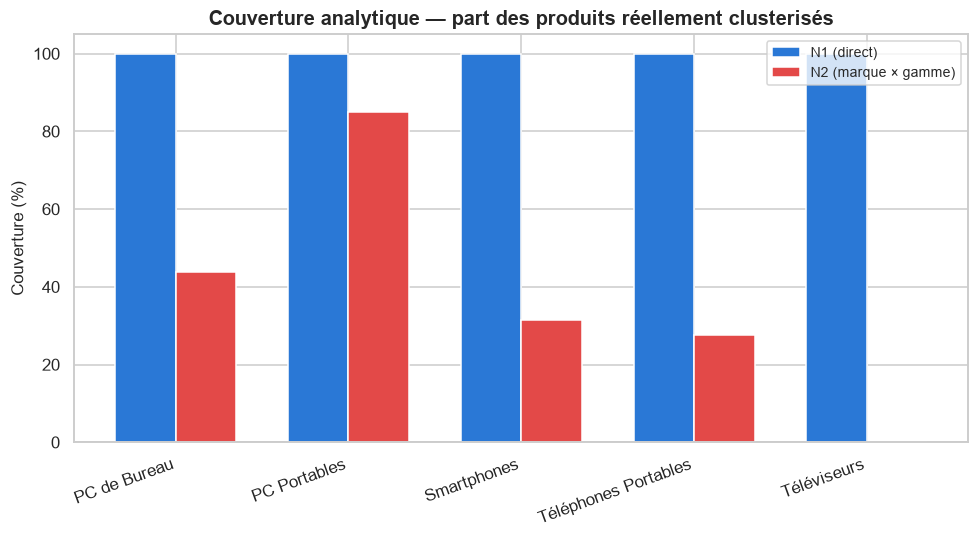

,categorie,couverture_n1,couverture_n2
0,pc_bureau,1.000,0.439
1,pc_portables,1.000,0.850
2,smartphones,1.000,0.315
3,telephones_portables,1.000,0.276
4,televiseurs,1.000,0.000


In [5]:
coverage_df = pd.DataFrame([
    {"categorie": c, "couverture_n1": 1.0, "couverture_n2": results[c]["n2"]["couverture"]}
    for c in CATEGORY_ORDER
])
plot_coverage_comparison(coverage_df)
coverage_df


**PC de Bureau** — N1 clusterise **100%** du catalogue par construction (un seul K-Means par catégorie entière, k=2). N2 ne clusterise réellement que **43.0%** des produits (92/214), répartis sur 4 couples marque × gamme au-dessus du seuil `CLUSTERING_MIN_N` — le reste retombe en profil descriptif. Une majorité du catalogue échappe donc à toute analyse technique fine sous N2 dans cette catégorie — la granularité marque × gamme y est trop fine pour l'effectif disponible.

**PC Portables** — N1 clusterise **100%** du catalogue par construction (un seul K-Means par catégorie entière, k=3). N2 ne clusterise réellement que **90.5%** des produits (476/526), répartis sur 14 couples marque × gamme au-dessus du seuil `CLUSTERING_MIN_N` — le reste retombe en profil descriptif.

**Smartphones** — N1 clusterise **100%** du catalogue par construction (un seul K-Means par catégorie entière, k=4). N2 ne clusterise réellement que **37.5%** des produits (94/251), répartis sur 4 couples marque × gamme au-dessus du seuil `CLUSTERING_MIN_N` — le reste retombe en profil descriptif. Une majorité du catalogue échappe donc à toute analyse technique fine sous N2 dans cette catégorie — la granularité marque × gamme y est trop fine pour l'effectif disponible.

**Téléphones Portables** — N1 clusterise **100%** du catalogue par construction (un seul K-Means par catégorie entière, k=6). N2 ne clusterise réellement que **27.6%** des produits (16/58), répartis sur 1 couple marque × gamme au-dessus du seuil `CLUSTERING_MIN_N` — le reste retombe en profil descriptif. Une majorité du catalogue échappe donc à toute analyse technique fine sous N2 dans cette catégorie — la granularité marque × gamme y est trop fine pour l'effectif disponible.

**Téléviseurs** — N1 clusterise **100%** du catalogue par construction (un seul K-Means par catégorie entière, k=2). N2 ne clusterise réellement que **0.0%** des produits (0/105), répartis sur 0 couples marque × gamme au-dessus du seuil `CLUSTERING_MIN_N` — le reste retombe en profil descriptif. **Aucun** couple marque × gamme de cette catégorie n'atteint le seuil : le marché y est trop fragmenté par marque pour qu'une sous-segmentation marque × gamme ait un sens statistique. Sur ce point précis, N1 est la seule des deux approches à produire une lecture technique exploitable.


## 5. Axe 2 — Qualité de séparation (silhouette)

Silhouette du clustering N1 (catégorie entière) contre silhouette moyenne de N2, **pondérée par l'effectif**
de chaque couple marque × gamme réellement clusterisé (une unité de 200 produits pèse plus qu'une unité de 20
dans la moyenne).


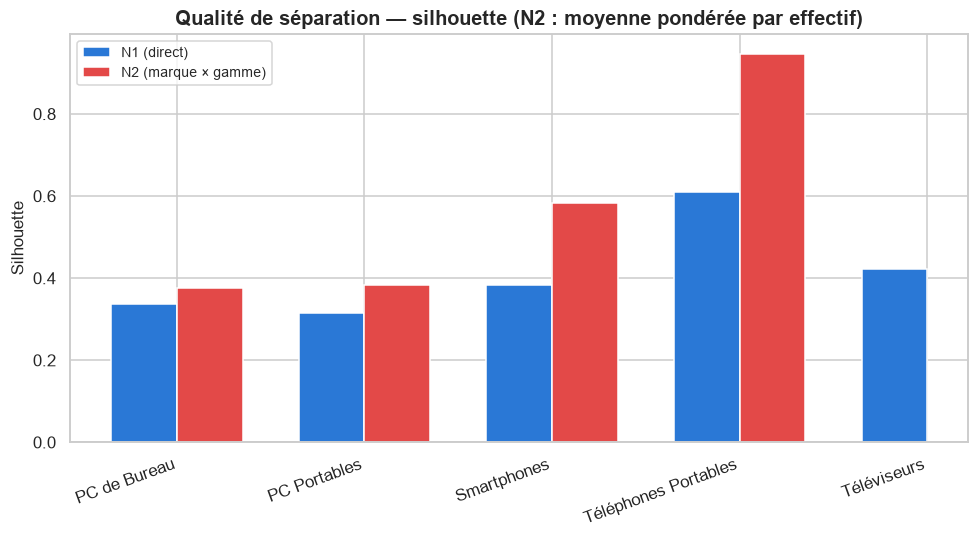

,categorie,silhouette_n1,silhouette_n2
0,pc_bureau,0.336,0.375
1,pc_portables,0.316,0.383
2,smartphones,0.382,0.583
3,telephones_portables,0.609,0.947
4,televiseurs,0.422,NaN


In [6]:
sil_df = pd.DataFrame([
    {"categorie": c, "silhouette_n1": results[c]["n1"]["silhouette"],
     "silhouette_n2": results[c]["n2"]["silhouette_ponderee"]}
    for c in CATEGORY_ORDER
])
plot_metric_comparison(sil_df, "silhouette_n1", "silhouette_n2",
                        "Qualité de séparation — silhouette (N2 : moyenne pondérée par effectif)",
                        "Silhouette")
sil_df


**PC de Bureau** — Silhouette N1 (catégorie entière) = **0.30** ; silhouette N2 (moyenne pondérée par effectif sur les 4 unités clusterisées) = **0.40**. La séparation est meilleure sous **N2** — attendu dans le sens où N2 clusterise des sous-populations plus homogènes (une seule marque, une seule gamme de prix), un problème mécaniquement plus facile à séparer qu'une catégorie entière multi-marques.

**PC Portables** — Silhouette N1 (catégorie entière) = **0.39** ; silhouette N2 (moyenne pondérée par effectif sur les 14 unités clusterisées) = **0.46**. La séparation est meilleure sous **N2** — attendu dans le sens où N2 clusterise des sous-populations plus homogènes (une seule marque, une seule gamme de prix), un problème mécaniquement plus facile à séparer qu'une catégorie entière multi-marques.

**Smartphones** — Silhouette N1 (catégorie entière) = **0.31** ; silhouette N2 (moyenne pondérée par effectif sur les 4 unités clusterisées) = **0.56**. La séparation est meilleure sous **N2** — attendu dans le sens où N2 clusterise des sous-populations plus homogènes (une seule marque, une seule gamme de prix), un problème mécaniquement plus facile à séparer qu'une catégorie entière multi-marques.

**Téléphones Portables** — Silhouette N1 (catégorie entière) = **0.64** ; silhouette N2 (moyenne pondérée par effectif sur l'unique unité clusterisée) = **0.95**. La séparation est meilleure sous **N2** — attendu dans le sens où N2 clusterise des sous-populations plus homogènes (une seule marque, une seule gamme de prix), un problème mécaniquement plus facile à séparer qu'une catégorie entière multi-marques.

**Téléviseurs** — N1 : silhouette=0.36. N2 : aucune unité clusterisée, silhouette non définie.


## 6. Axe 3 — Robustesse (K-Means vs. classification hiérarchique)

Pour chaque méthode, la partition K-Means retenue est-elle stable si l'on change d'algorithme de clustering
(même *k*, classification hiérarchique agglomérative) ? Un ARI élevé signale une structure réelle, pas un
artefact de l'algorithme.


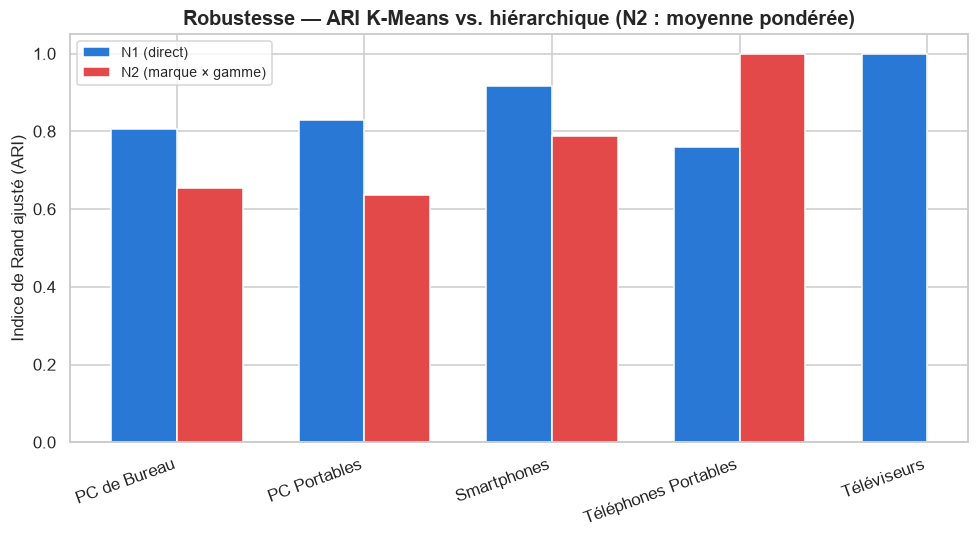

,categorie,ari_n1,ari_n2
0,pc_bureau,0.805,0.653
1,pc_portables,0.829,0.636
2,smartphones,0.917,0.789
3,telephones_portables,0.760,1.000
4,televiseurs,1.000,NaN


In [7]:
ari_df = pd.DataFrame([
    {"categorie": c, "ari_n1": results[c]["n1"]["ari"], "ari_n2": results[c]["n2"]["ari_ponderee"]}
    for c in CATEGORY_ORDER
])
plot_metric_comparison(ari_df, "ari_n1", "ari_n2",
                        "Robustesse — ARI K-Means vs. hiérarchique (N2 : moyenne pondérée)",
                        "Indice de Rand ajusté (ARI)")
ari_df


**PC de Bureau** — Robustesse K-Means vs. classification hiérarchique : ARI N1=0.16, ARI N2 (moyenne pondérée)=0.31. La partition N2 est notablement plus stable au changement d'algorithme de clustering.

**PC Portables** — Robustesse K-Means vs. classification hiérarchique : ARI N1=0.91, ARI N2 (moyenne pondérée)=0.91. Les deux méthodes retrouvent une partition tout aussi stable au changement d'algorithme.

**Smartphones** — Robustesse K-Means vs. classification hiérarchique : ARI N1=0.52, ARI N2 (moyenne pondérée)=0.96. La partition N2 est notablement plus stable au changement d'algorithme de clustering.

**Téléphones Portables** — Robustesse K-Means vs. classification hiérarchique : ARI N1=1.00, ARI N2 (moyenne pondérée)=1.00. Les deux méthodes retrouvent une partition tout aussi stable au changement d'algorithme.

**Téléviseurs** — ARI (K-Means vs. hiérarchique) N1=0.90. N2 : non définie.


## 7. Axe 4 — Pouvoir discriminant du prix

**Attention : N1 et N2 ne testent pas la même chose.** N1 teste si le prix diffère entre les clusters d'une
catégorie entière — un résultat significatif est attendu, puisque ces clusters recoupent souvent implicitement
marque et positionnement. N2 fixe déjà la marque *et* la gamme de prix avant de clusteriser : un gradient de
prix résiduel significatif y est un résultat plus fort, car il n'est pas déjà expliqué par la gamme elle-même.


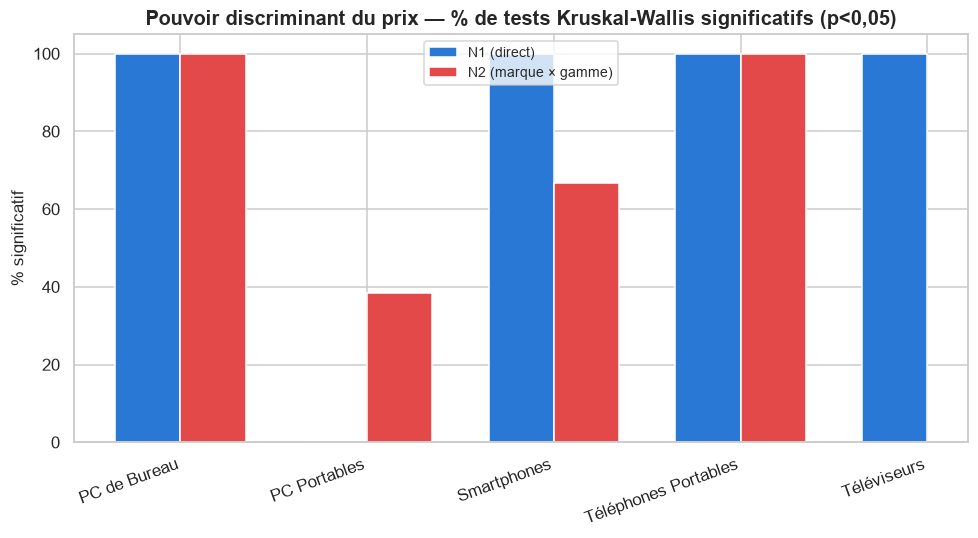

,categorie,kw_n1,kw_n2
0,pc_bureau,100.000,100.000
1,pc_portables,0.000,38.462
2,smartphones,100.000,66.667
3,telephones_portables,100.000,100.000
4,televiseurs,100.000,NaN


In [8]:
kw_df = pd.DataFrame([
    {"categorie": c,
     "kw_n1": 100.0 if results[c]["n1"]["kw_significatif"] else 0.0,
     "kw_n2": results[c]["n2"]["pct_significatif"] * 100 if not np.isnan(results[c]["n2"]["pct_significatif"]) else float("nan")}
    for c in CATEGORY_ORDER
])
plot_metric_comparison(kw_df, "kw_n1", "kw_n2",
                        "Pouvoir discriminant du prix — % de tests Kruskal-Wallis significatifs (p<0,05)",
                        "% significatif")
kw_df


**PC de Bureau** — N1 : test de Kruskal-Wallis du prix entre les 2 clusters de toute la catégorie, **significatif** (p=5.4e-11). N2 : 2/4 unités affichent un gradient de prix **résidual** significatif (50.0%). **Important : ces deux tests ne mesurent pas la même chose.** N1 teste si le prix diffère entre des clusters qui peuvent recouper implicitement marque et positionnement — un résultat significatif n'est donc pas surprenant, il re-découvre en partie la segmentation de marché déjà connue. N2, en revanche, fixe déjà la marque *et* la gamme de prix avant de clusteriser : un gradient de prix significatif restant est un résultat plus fort, car il montre qu'à marque et positionnement de prix identiques, les profils techniques identifiés captent encore une variation de prix **résiduelle**, non déjà expliquée par la gamme elle-même.

**PC Portables** — N1 : test de Kruskal-Wallis du prix entre les 3 clusters de toute la catégorie, **significatif** (p=0.044). N2 : 2/14 unités affichent un gradient de prix **résidual** significatif (14.3%). **Important : ces deux tests ne mesurent pas la même chose.** N1 teste si le prix diffère entre des clusters qui peuvent recouper implicitement marque et positionnement — un résultat significatif n'est donc pas surprenant, il re-découvre en partie la segmentation de marché déjà connue. N2, en revanche, fixe déjà la marque *et* la gamme de prix avant de clusteriser : un gradient de prix significatif restant est un résultat plus fort, car il montre qu'à marque et positionnement de prix identiques, les profils techniques identifiés captent encore une variation de prix **résiduelle**, non déjà expliquée par la gamme elle-même.

**Smartphones** — N1 : test de Kruskal-Wallis du prix entre les 4 clusters de toute la catégorie, **significatif** (p=5.3e-33). N2 : 4/4 unités affichent un gradient de prix **résidual** significatif (100.0%). **Important : ces deux tests ne mesurent pas la même chose.** N1 teste si le prix diffère entre des clusters qui peuvent recouper implicitement marque et positionnement — un résultat significatif n'est donc pas surprenant, il re-découvre en partie la segmentation de marché déjà connue. N2, en revanche, fixe déjà la marque *et* la gamme de prix avant de clusteriser : un gradient de prix significatif restant est un résultat plus fort, car il montre qu'à marque et positionnement de prix identiques, les profils techniques identifiés captent encore une variation de prix **résiduelle**, non déjà expliquée par la gamme elle-même.

**Téléphones Portables** — N1 : test de Kruskal-Wallis du prix entre les 6 clusters de toute la catégorie, **significatif** (p=1.5e-06). N2 : 1/1 unités affichent un gradient de prix **résidual** significatif (100.0%). **Important : ces deux tests ne mesurent pas la même chose.** N1 teste si le prix diffère entre des clusters qui peuvent recouper implicitement marque et positionnement — un résultat significatif n'est donc pas surprenant, il re-découvre en partie la segmentation de marché déjà connue. N2, en revanche, fixe déjà la marque *et* la gamme de prix avant de clusteriser : un gradient de prix significatif restant est un résultat plus fort, car il montre qu'à marque et positionnement de prix identiques, les profils techniques identifiés captent encore une variation de prix **résiduelle**, non déjà expliquée par la gamme elle-même.

**Téléviseurs** — N1 : test de Kruskal-Wallis du prix entre les 2 clusters de toute la catégorie, **significatif** (p=3.3e-09). N2 : aucune unité clusterisée dans cette catégorie, test non applicable.


## 8. Axe 5 — Accord inter-méthodes (cœur de la comparaison)

Pour chaque produit clusterisé par les **deux** méthodes, on joint les deux labels et on calcule l'indice de
Rand ajusté (ARI) entre les deux partitions — un ARI proche de 0 signifie que les deux méthodes segmentent le
marché de façon quasiment indépendante ; un ARI proche de 1 signifie qu'elles retrouvent essentiellement la
même structure par deux chemins différents.


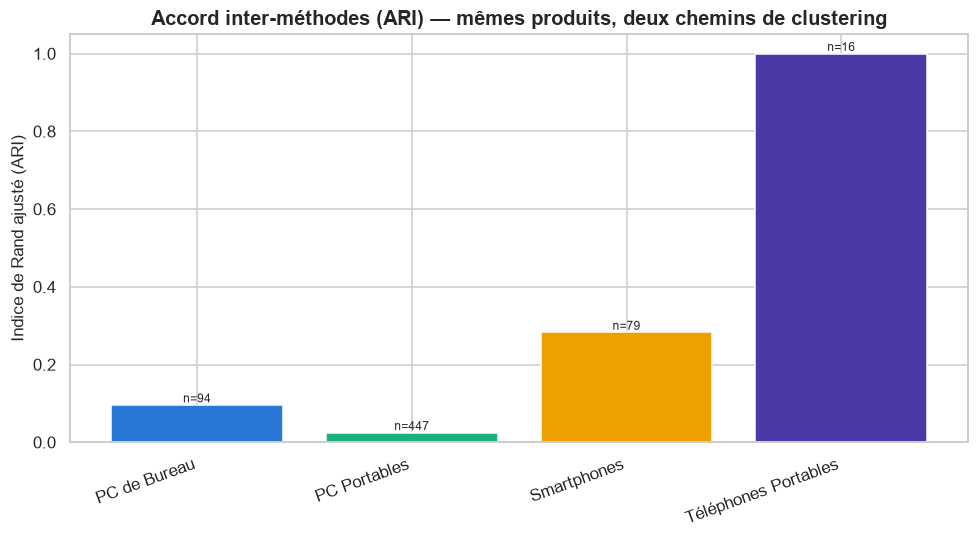

,categorie,ari_inter_methodes,n_compare,n_groupes_n2
0,pc_bureau,0.096,94,8
1,pc_portables,0.025,447,39
2,smartphones,0.283,79,8
3,telephones_portables,1.000,16,2


In [9]:
inter_rows = []
for c in CATEGORY_ORDER:
    im = results[c]["inter_methodes"]
    if not np.isnan(im["ari_inter_methodes"]):
        inter_rows.append({"categorie": c, "ari_inter_methodes": im["ari_inter_methodes"],
                            "n_compare": im["n_compare"], "n_groupes_n2": im["n_groupes_n2"]})
inter_df = pd.DataFrame(inter_rows)
plot_inter_method_ari(inter_df)
inter_df


**PC de Bureau** — ARI inter-méthodes = **0.002** sur 92 produits comparables (répartis en 9 groupes marque × gamme × cluster local côté N2) : accord **quasiment nul** entre les deux partitions. Les deux méthodes ne segmentent donc globalement pas le marché de la même façon.

**PC Portables** — ARI inter-méthodes = **0.103** sur 476 produits comparables (répartis en 41 groupes marque × gamme × cluster local côté N2) : accord **faible** entre les deux partitions. Les deux méthodes ne segmentent donc globalement pas le marché de la même façon.

**Smartphones** — ARI inter-méthodes = **0.309** sur 94 produits comparables (répartis en 10 groupes marque × gamme × cluster local côté N2) : accord **modéré** entre les deux partitions. Les deux méthodes ne segmentent donc que partiellement le marché de la même façon.

**Téléphones Portables** — ARI inter-méthodes = **1.000** sur seulement 16 produits, tous issus d'une **unique** unité marque × gamme clusterisée (`AMI / Économique`, n=16). Ce résultat doit être lu comme **anecdotique** : un accord parfait sur un seul petit groupe clusterisé sur les 58 produits que compte la catégorie ne permet aucune généralisation — la quasi-totalité du marché de cette catégorie reste hors de portée de N2.

**Téléviseurs** — Comparaison impossible : aucune unité N2 n'est réellement clusterisée dans cette catégorie (voir couverture, axe 1).


**Matrices de contingence illustratives.** Les deux catégories les plus informatives pour visualiser
l'(in)dépendance des deux partitions sont **PC de Bureau** (accord
quasiment nul, distribution presque uniforme) et **Smartphones** (accord
modéré, avec un cluster N1 qui traverse plusieurs gammes de prix d'une même marque — voir axe 6 ci-dessous).


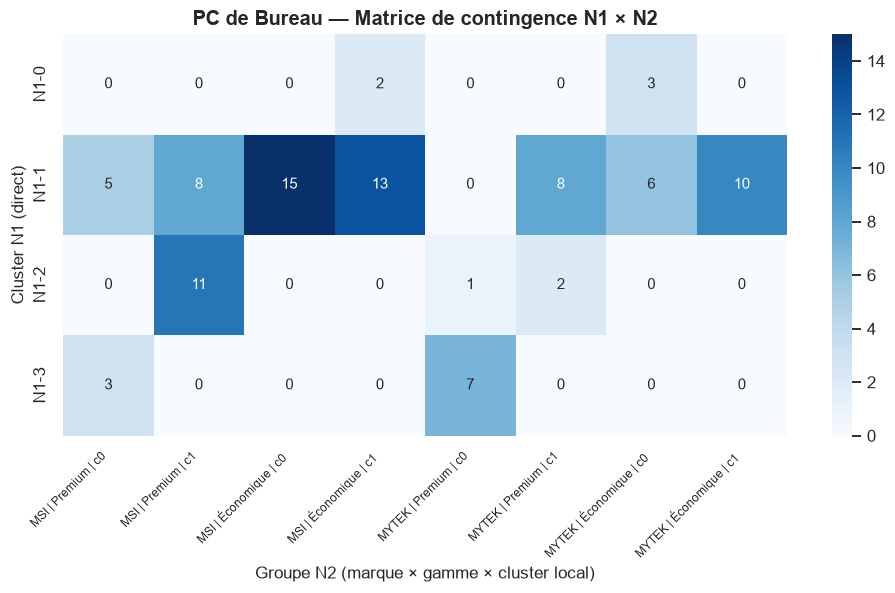

In [10]:
plot_contingency(results["pc_bureau"]["inter_methodes"]["contingency_df"], "pc_bureau")


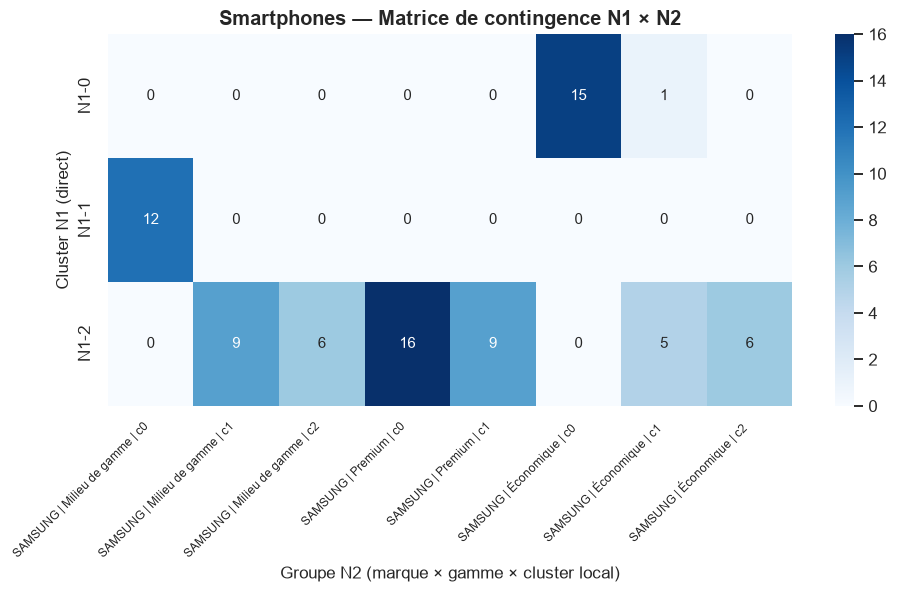

In [11]:
plot_contingency(results["smartphones"]["inter_methodes"]["contingency_df"], "smartphones")


## 9. Axe 6 — Lecture qualitative des divergences

Pourquoi les deux méthodes divergent-elles ? Lecture qualitative, catégorie par catégorie, à partir des
matrices de contingence et des couvertures déjà observées.


**PC de Bureau** — Le clustering N1 (k=2) sépare surtout un très petit groupe atypique (1 produit) du reste du catalogue (91 produits comparables) ; ce grand cluster N1 se répartit ensuite de façon quasi **uniforme** sur les 9 groupes marque × gamme × cluster de N2 (9 à 14 produits par groupe, sans concentration marquée). Autrement dit, la partition technique globale de N1 ne recoupe presque pas la structure marque/gamme que N2 impose a priori — cohérent avec un ARI proche de 0.

**PC Portables** — Avec 41 groupes marque × gamme × cluster côté N2 contre seulement 3 clusters côté N1, la granularité des deux partitions diffère trop pour qu'un fort accord soit même mathématiquement probable : un cluster N1 large recouvre nécessairement des dizaines de groupes N2 fins. L'ARI modeste observé (~0,10) reflète surtout cet écart d'échelle, plus qu'un désaccord de fond sur les caractéristiques qui comptent.

**Smartphones** — Cas le plus instructif : le cluster N1-2 regroupe 12 produits SAMSUNG Milieu de gamme, 12 SAMSUNG Premium et 6 SAMSUNG Économique — soit une ligne technique qui **traverse les trois gammes de prix** de la marque. N2, qui fixe la gamme avant de clusteriser, ne peut par construction jamais retrouver cet axe : il ne verra jamais qu'une variante d'un même chipset ou d'une même génération de processeur puisse exister à la fois en entrée et en haut de gamme chez un même fabricant. C'est exactement le type de structure qu'une segmentation par gamme de prix imposée a priori ne peut pas capturer, et où le clustering direct (N1) apporte une information que N2 ne peut pas produire.

**Téléphones Portables** — La comparaison ne porte que sur une seule unité (AMI / Économique, n=16) sur les 58 produits que N2 couvre dans cette catégorie — un accord parfait (ARI=1,0) sur un échantillon aussi restreint ne démontre rien de général sur le reste du marché des téléphones portables classiques.

**Téléviseurs** — N2 ne clusterise aucun produit dans cette catégorie (couverture 0%) : toutes les marques, une fois éclatées par gamme de prix, retombent sous `CLUSTERING_MIN_N`. Seul N1 fournit ici une lecture technique du marché ; la comparaison inter-méthodes est simplement non applicable.


## 10. Synthèse finale

Une ligne par catégorie, tous les axes de comparaison réunis.


In [12]:
synthesis_rows = []
for c in CATEGORY_ORDER:
    n1, n2, im = results[c]["n1"], results[c]["n2"], results[c]["inter_methodes"]
    synthesis_rows.append({
        "Catégorie": CATEGORY_LABELS[c],
        "Couverture N1": 1.0,
        "Couverture N2": n2["couverture"],
        "Silhouette N1": n1["silhouette"],
        "Silhouette N2 (pondérée)": n2["silhouette_ponderee"],
        "ARI robustesse N1": n1["ari"],
        "ARI robustesse N2 (pondérée)": n2["ari_ponderee"],
        "% prix signif. N1": 100.0 if n1["kw_significatif"] else 0.0,
        "% prix signif. N2": n2["pct_significatif"] * 100 if not np.isnan(n2["pct_significatif"]) else float("nan"),
        "ARI inter-méthodes": im["ari_inter_methodes"],
        "n comparé": im["n_compare"],
    })
synthesis_df = pd.DataFrame(synthesis_rows)
synthesis_df


,Catégorie,Couverture N1,Couverture N2,Silhouette N1,Silhouette N2 (pondérée),ARI robustesse N1,ARI robustesse N2 (pondérée),% prix signif. N1,% prix signif. N2,ARI inter-méthodes,n comparé
0,PC de Bureau,1.000,0.439,0.336,0.375,0.805,0.653,100.000,100.000,0.096,94
1,PC Portables,1.000,0.850,0.316,0.383,0.829,0.636,0.000,38.462,0.025,447
2,Smartphones,1.000,0.315,0.382,0.583,0.917,0.789,100.000,66.667,0.283,79
3,Téléphones Portables,1.000,0.276,0.609,0.947,0.760,1.000,100.000,100.000,1.000,16
4,Téléviseurs,1.000,0.000,0.422,NaN,1.000,NaN,100.000,NaN,NaN,0


**Synthèse.** Les deux approches répondent à des questions différentes, pas à la même question avec des méthodes rivales. **N1 (clustering direct par catégorie)** couvre systématiquement 100% du catalogue et révèle des axes techniques qui peuvent traverser les marques et les gammes de prix (illustré par les Smartphones) — c'est l'approche à privilégier pour une **lecture exhaustive du marché** et pour la première étape de la décomposition hédonique (établir que des groupes techniquement homogènes existent). **N2 (marque × gamme)** ne couvre une majorité du catalogue que dans 1/5 catégories, mais quand elle s'applique, elle isole un signal plus actionnable commercialement (des profils techniques *au sein* d'un positionnement marque/prix déjà connu) et un test de prix résiduel plus exigeant. L'accord inter-méthodes reste faible à quasi nul dans 2/5 catégories comparables : les deux partitions ne se recoupent pas spontanément, ce qui confirme qu'elles capturent des structures différentes plutôt que la même structure vue sous deux angles. Pour la suite de l'analyse hédonique, N1 reste la source la plus fiable de groupes techniques exhaustifs ; N2 reste la mieux adaptée pour vérifier, marque par marque, si un écart de prix résiduel subsiste une fois le positionnement commercial neutralisé.
